# <center> <img src="../img/ITESOLogo.png" alt="ITESO" width="480" height="130"> </center>
# <center> **Departamento de Electrónica, Sistemas e Informática** </center>
---
## <center> **Big Data** </center>
---
### <center> **Spring 2026** </center>
---
### <center> **Examples on Structured Streaming (Kakfa producer)** </center>
---
**Profesor**: Pablo Camarillo Ramirez

# Create SparkSession

In [1]:
from pcamarillor.spark_utils import SparkUtils
from pathlib import Path
import shutil
import pyspark.sql.functions as F

kafka_connector = "org.apache.spark:spark-sql-kafka-0-10_2.13:4.0.0"
su = SparkUtils("Example Kafka", 
                "spark://spark-master:7077",
                spark_packages=kafka_connector)
su.spark


:: loading settings :: url = jar:file:/opt/spark/jars/ivy-2.5.3.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /root/.ivy2.5.2/cache
The jars for the packages stored in: /root/.ivy2.5.2/jars
org.apache.spark#spark-sql-kafka-0-10_2.13 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-0d8696ba-5228-4478-8b1a-d7993216cedf;1.0
	confs: [default]
	found org.apache.spark#spark-sql-kafka-0-10_2.13;4.0.0 in central
	found org.apache.spark#spark-token-provider-kafka-0-10_2.13;4.0.0 in central
	found org.apache.kafka#kafka-clients;3.9.0 in central
	found org.lz4#lz4-java;1.8.0 in central
	found org.xerial.snappy#snappy-java;1.1.10.7 in central
	found org.slf4j#slf4j-api;2.0.16 in central
	found org.apache.hadoop#hadoop-client-runtime;3.4.1 in central
	found org.apache.hadoop#hadoop-client-api;3.4.1 in central
	found com.google.code.findbugs#jsr305;3.0.0 in central
	found org.scala-lang.modules#scala-parallel-collections_2.13;1.2.0

# Create a data stream from a Kafka topic

In [2]:
# Create the remote connection
kafka_df = su.spark.readStream \
            .format("kafka") \
            .option("kafka.bootstrap.servers", "kafka:9093") \
            .option("subscribe", "test-topic-2") \
            .load()

kafka_df.printSchema()

# Transform binary data to string
df_input = kafka_df.selectExpr("CAST(value AS STRING)")

# Clean checkpoint
checkpoint_path = "/opt/spark/work-dir/checkpoints/logs_checkpoint"
dir_path = Path(checkpoint_path)
if dir_path.exists() and dir_path.is_dir():
    shutil.rmtree(dir_path)

words = df_input.select(F.explode(F.split(df_input.value, " ")).alias("word"))
word_count = words.groupBy("word").count()

# Send transformed data to the Sink
query_a = (word_count.writeStream
            .trigger(processingTime='2 second')
            .outputMode("complete")
            .format("console")
            .option("checkpointLocation", checkpoint_path)
            .start())

print("   Press Ctrl+C to stop.\n")
su.spark.streams.awaitAnyTermination()

root
 |-- key: binary (nullable = true)
 |-- value: binary (nullable = true)
 |-- topic: string (nullable = true)
 |-- partition: integer (nullable = true)
 |-- offset: long (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- timestampType: integer (nullable = true)



26/04/18 05:36:14 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.


   Press Ctrl+C to stop.



26/04/18 05:36:14 WARN KafkaOffsetReaderAdmin: Error in attempt 1 getting Kafka offsets: 
java.util.concurrent.ExecutionException: org.apache.kafka.common.errors.UnknownTopicOrPartitionException: This server does not host this topic-partition.
	at java.base/java.util.concurrent.CompletableFuture.reportGet(CompletableFuture.java:396)
	at java.base/java.util.concurrent.CompletableFuture.get(CompletableFuture.java:2073)
	at org.apache.kafka.common.internals.KafkaFutureImpl.get(KafkaFutureImpl.java:165)
	at org.apache.spark.sql.kafka010.ConsumerStrategy.retrieveAllPartitions(ConsumerStrategy.scala:65)
	at org.apache.spark.sql.kafka010.ConsumerStrategy.retrieveAllPartitions$(ConsumerStrategy.scala:64)
	at org.apache.spark.sql.kafka010.SubscribeStrategy.retrieveAllPartitions(ConsumerStrategy.scala:101)
	at org.apache.spark.sql.kafka010.SubscribeStrategy.assignedTopicPartitions(ConsumerStrategy.scala:112)
	at org.apache.spark.sql.kafka010.KafkaOffsetReaderAdmin.$anonfun$partitionsAssignedToAd

StreamingQueryException: [STREAM_FAILED] Query [id = af772eac-3a2a-4a4d-b96c-da678ccd1f65, runId = 5686fc69-cf18-4e84-8b30-c04ed644a0bb] terminated with exception: org.apache.kafka.common.errors.UnknownTopicOrPartitionException: This server does not host this topic-partition. SQLSTATE: XXKST
=== Streaming Query ===
Identifier: [id = af772eac-3a2a-4a4d-b96c-da678ccd1f65, runId = 5686fc69-cf18-4e84-8b30-c04ed644a0bb]
Current Committed Offsets: {}
Current Available Offsets: {}

Current State: ACTIVE
Thread State: RUNNABLE

Logical Plan:
~WriteToMicroBatchDataSource org.apache.spark.sql.execution.streaming.ConsoleTable$@73a46cda, af772eac-3a2a-4a4d-b96c-da678ccd1f65, [checkpointLocation=/opt/spark/work-dir/checkpoints/logs_checkpoint], Complete
+- ~Aggregate [word#16], [word#16, count(1) AS count#17L]
   +- ~Project [word#16]
      +- ~Generate explode(split(value#14,  , -1)), false, [word#16]
         +- ~Project [cast(value#8 as string) AS value#14]
            +- ~StreamingDataSourceV2S

## Custom producer

### Create `server-logs` topic

```
    docker exec -it <Kafka container ID> \
     /opt/kafka/bin/kafka-topics.sh \
      --create --zookeeper zookeeper:2181 \
      --replication-factor 1 --partitions 1 \
      --topic server-logs
```

### Run the producer

```
    docker exec -it <Spark-Notebook container ID> /bin/bash
    # cd src/producers/
    # python3 kafka_producer.py --broker kafka:9093 --topic server-logs --records 20
```

### Run the consumer code

In [3]:
# Create the remote connection
server_logs_df = (su.spark.readStream
            .format("kafka")
            .option("kafka.bootstrap.servers", "kafka:9093")
            .option("subscribe", "server-logs")
            .load())

# Transform binary data to string
logs_df = server_logs_df.selectExpr("CAST(value AS STRING)")

# Clean checkpoint
checkpoint_path = "/opt/spark/work-dir/checkpoints/logs_checkpoint"
dir_path = Path(checkpoint_path)
if dir_path.exists() and dir_path.is_dir():
    shutil.rmtree(dir_path)

# Transform original dataframe
parsed_df = (
    logs_df
    .withColumn("parts",     F.split(F.col("value"), r" \| "))
    .withColumn("timestamp", F.to_timestamp(F.col("parts")[0], "yyyy-MM-dd HH:mm:ss"))
    .withColumn("level",     F.trim(F.col("parts")[1]))
    .withColumn("message",   F.trim(F.col("parts")[2]))
    .withColumn("server",    F.trim(F.col("parts")[3]))
    .drop("parts", "value")
    .filter(F.col("timestamp").isNotNull())
)

# Write stream in the destination
output_path = "/opt/spark/work-dir/data/streaming/output/"
query_events = (
    parsed_df.writeStream
    .outputMode("append")
    .format("parquet")
    .option("truncate", False)
    .option("checkpointLocation", checkpoint_path)
    .option("path", output_path)
    .partitionBy("server", "level")
    .start()
)

print("   Press Ctrl+C to stop.\n")
su.spark.streams.awaitAnyTermination()

   Press Ctrl+C to stop.



26/04/18 05:36:22 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.


StreamingQueryException: [STREAM_FAILED] Query [id = af772eac-3a2a-4a4d-b96c-da678ccd1f65, runId = 5686fc69-cf18-4e84-8b30-c04ed644a0bb] terminated with exception: org.apache.kafka.common.errors.UnknownTopicOrPartitionException: This server does not host this topic-partition. SQLSTATE: XXKST
=== Streaming Query ===
Identifier: [id = af772eac-3a2a-4a4d-b96c-da678ccd1f65, runId = 5686fc69-cf18-4e84-8b30-c04ed644a0bb]
Current Committed Offsets: {}
Current Available Offsets: {}

Current State: ACTIVE
Thread State: RUNNABLE

Logical Plan:
~WriteToMicroBatchDataSource org.apache.spark.sql.execution.streaming.ConsoleTable$@73a46cda, af772eac-3a2a-4a4d-b96c-da678ccd1f65, [checkpointLocation=/opt/spark/work-dir/checkpoints/logs_checkpoint], Complete
+- ~Aggregate [word#16], [word#16, count(1) AS count#17L]
   +- ~Project [word#16]
      +- ~Generate explode(split(value#14,  , -1)), false, [word#16]
         +- ~Project [cast(value#8 as string) AS value#14]
            +- ~StreamingDataSourceV2S

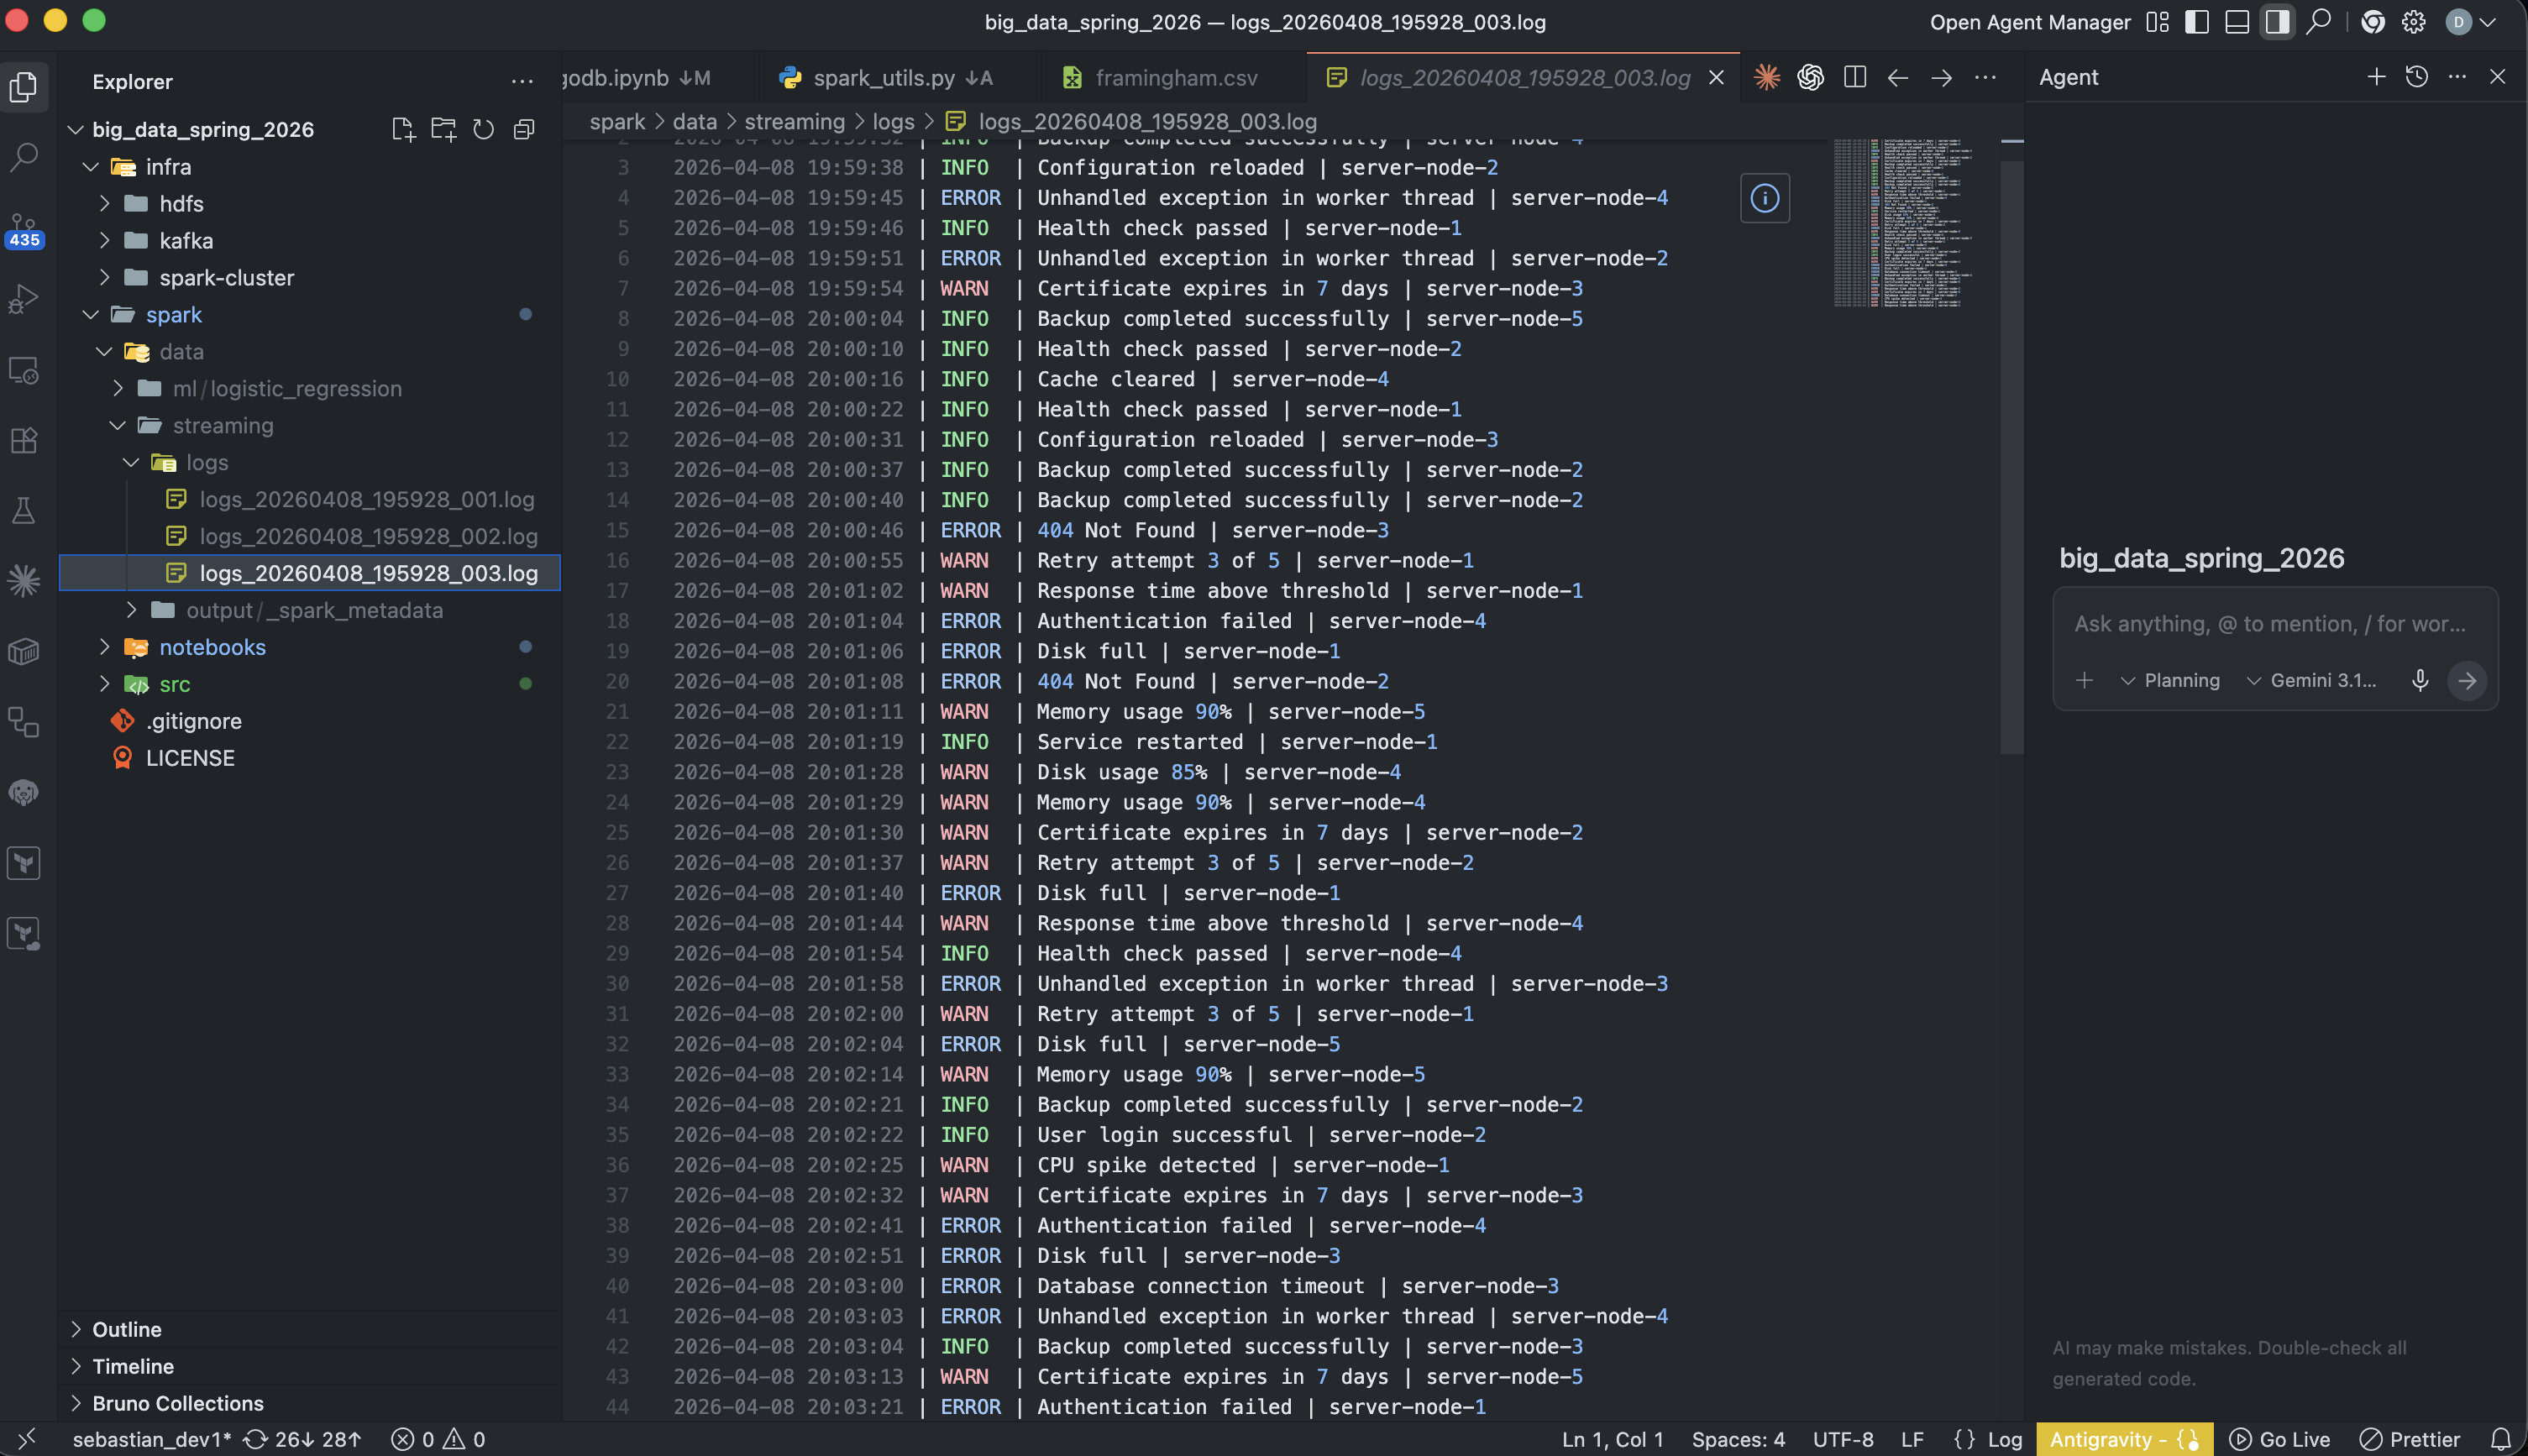

In [4]:
!ls -lah /opt/spark/work-dir/data/streaming/output/

total 0
drwxr-xr-x 3 root root  96 Apr 14 01:10 .
drwxr-xr-x 4 root root 128 Apr 14 01:10 ..
drwxr-xr-x 4 root root 128 Apr 14 01:10 _spark_metadata


In [4]:
su.spark.stop()